In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scienceplots
import scipy
from dotenv import load_dotenv
import os

import tensorstore as ts

load_dotenv()
PATH = os.getenv("ROOT_PATH")

plt.style.use(['science', 'no-latex'])

def format_ax(ax):
  for spine in ax.spines.values():
    spine.set_linewidth(1.2)
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  ax.spines['bottom'].set_visible(False)
  ax.tick_params(which='minor', length=0)
  ax.tick_params(axis='both', labelsize=12)
  for spine in ax.spines.values():
    spine.set_visible(False)
  ax.tick_params(axis='both', which='both', bottom=False, top=False, left=False, right=False, labelbottom=False, labelleft=False)
  ax.tick_params(axis='y', which='both', left=False, right=False, direction="out", width=1.2)

In [3]:
subject_id = "06"

traces = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': f'file:///{PATH}/ts_files/subject_{subject_id}_traces.zarr'
    # 'kvstore': 'gs://zapbench-release/volumes/20240930/traces/'
}).result()

s = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': f'file:///{PATH}/ts_files/subject_{subject_id}_stimuli.zarr'
    # 'kvstore': 'gs://zapbench-release/volumes/20240930/traces/'
}).result()

coordinates = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': f'file:///{PATH}/ts_files/subject_{subject_id}_coordinates.zarr'
    # 'kvstore': 'gs://zapbench-release/volumes/20240930/traces/'
}).result()

behavior = ts.open({
    'open': True,
    'driver': 'zarr3',
    'kvstore': f'file:///{PATH}/ts_files/subject_{subject_id}_behavioral_covariates.zarr'
    # 'kvstore': 'gs://zapbench-release/volumes/20240930/traces/'
}).result()

traces = traces.read().result()
s = s.read().result()
coordinates = coordinates.read().result()
behavior = behavior.read().result()

In [4]:
traces.shape, s.shape, coordinates.shape, behavior.shape

((3780, 92538), (3780, 16), (92538, 3), (3780, 5))

In [5]:
import h5py
import numpy as np
f = h5py.File(f'/{PATH}/Additional_mat_files/MaskDatabase.mat', 'r')
names = f['MaskDatabaseNames']
names = [(i, "".join([chr(c[0]) for c in f[name[0]]])) for i, name in enumerate(names)]

In [7]:
def linear_to_3d_matlab(linear_idx, width, height):
  idx = linear_idx - 1
  i = idx % width
  j = (idx // width) % height
  k = idx // (width * height)
  return i, j, k

def matlab_to_linear(i, j, k, width, height):
  linear_idx = i + j * width + k * width * height + 1
  return linear_idx


reference_anat = scipy.io.loadmat(f'/{PATH}/Additional_mat_files/ReferenceBrain.mat')['anat_stack_norm']

ir = f['MaskDatabase']['ir'][:]  # Row indices (linear voxel indices)
jc = f['MaskDatabase']['jc'][:]  # Column pointers
data = f['MaskDatabase']['data'][:]  # Should be all ones

mask = np.zeros_like(reference_anat)
mask_shape = mask.shape

# mask_idx_list = [77, 66, 67, 68, 69, 70, 71, 101, 102, 103]
mask_idx_list = [106] # visual processing
# mask_idx_list = [96, 97, 200] # eye movement control
for mask_idx in mask_idx_list:
  start_idx = jc[mask_idx]
  end_idx = jc[mask_idx + 1]
  for i in ir[start_idx:end_idx]:
    i_x, i_y, i_z = linear_to_3d_matlab(i, mask_shape[0], mask_shape[1])
    mask[i_x, i_y, i_z] = 1

In [8]:
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np

reference_anat[mask==0]=0

grid = pv.wrap(reference_anat)
grid.spacing = [1.0, 1.0, 2.0]
valid_coordinates = []
valid_coordinate_i = []
for i, c in enumerate(coordinates):
  if mask[c.astype(int)[0], c.astype(int)[1], c.astype(int)[2]]:
    valid_coordinates.append(c)
    valid_coordinate_i.append(i)
valid_coordinates = np.stack(valid_coordinates)
points = valid_coordinates * np.array(grid.spacing)
colors = np.random.rand(len(points))
point_cloud = pv.PolyData(points)

In [ ]:
pv.set_jupyter_backend('static')
plotter = pv.Plotter(notebook=True)
plotter.add_volume(
    grid,
    cmap="gray",
    opacity=[0.0,0.1,0.3,0.5],
    shade=True,
    show_scalar_bar=False,
)

colors=np.mean(traces[..., valid_coordinate_i], 0)>0.13
plotter.add_mesh(
    point_cloud,
    scalars=colors,
    cmap='viridis',
    point_size=5,
    render_points_as_spheres=True,
    show_scalar_bar=False
)

plotter.camera_position = 'xy'
plotter.camera.azimuth = 0
plotter.camera.elevation = 0
plotter.camera.zoom(1.5)
plotter.show()

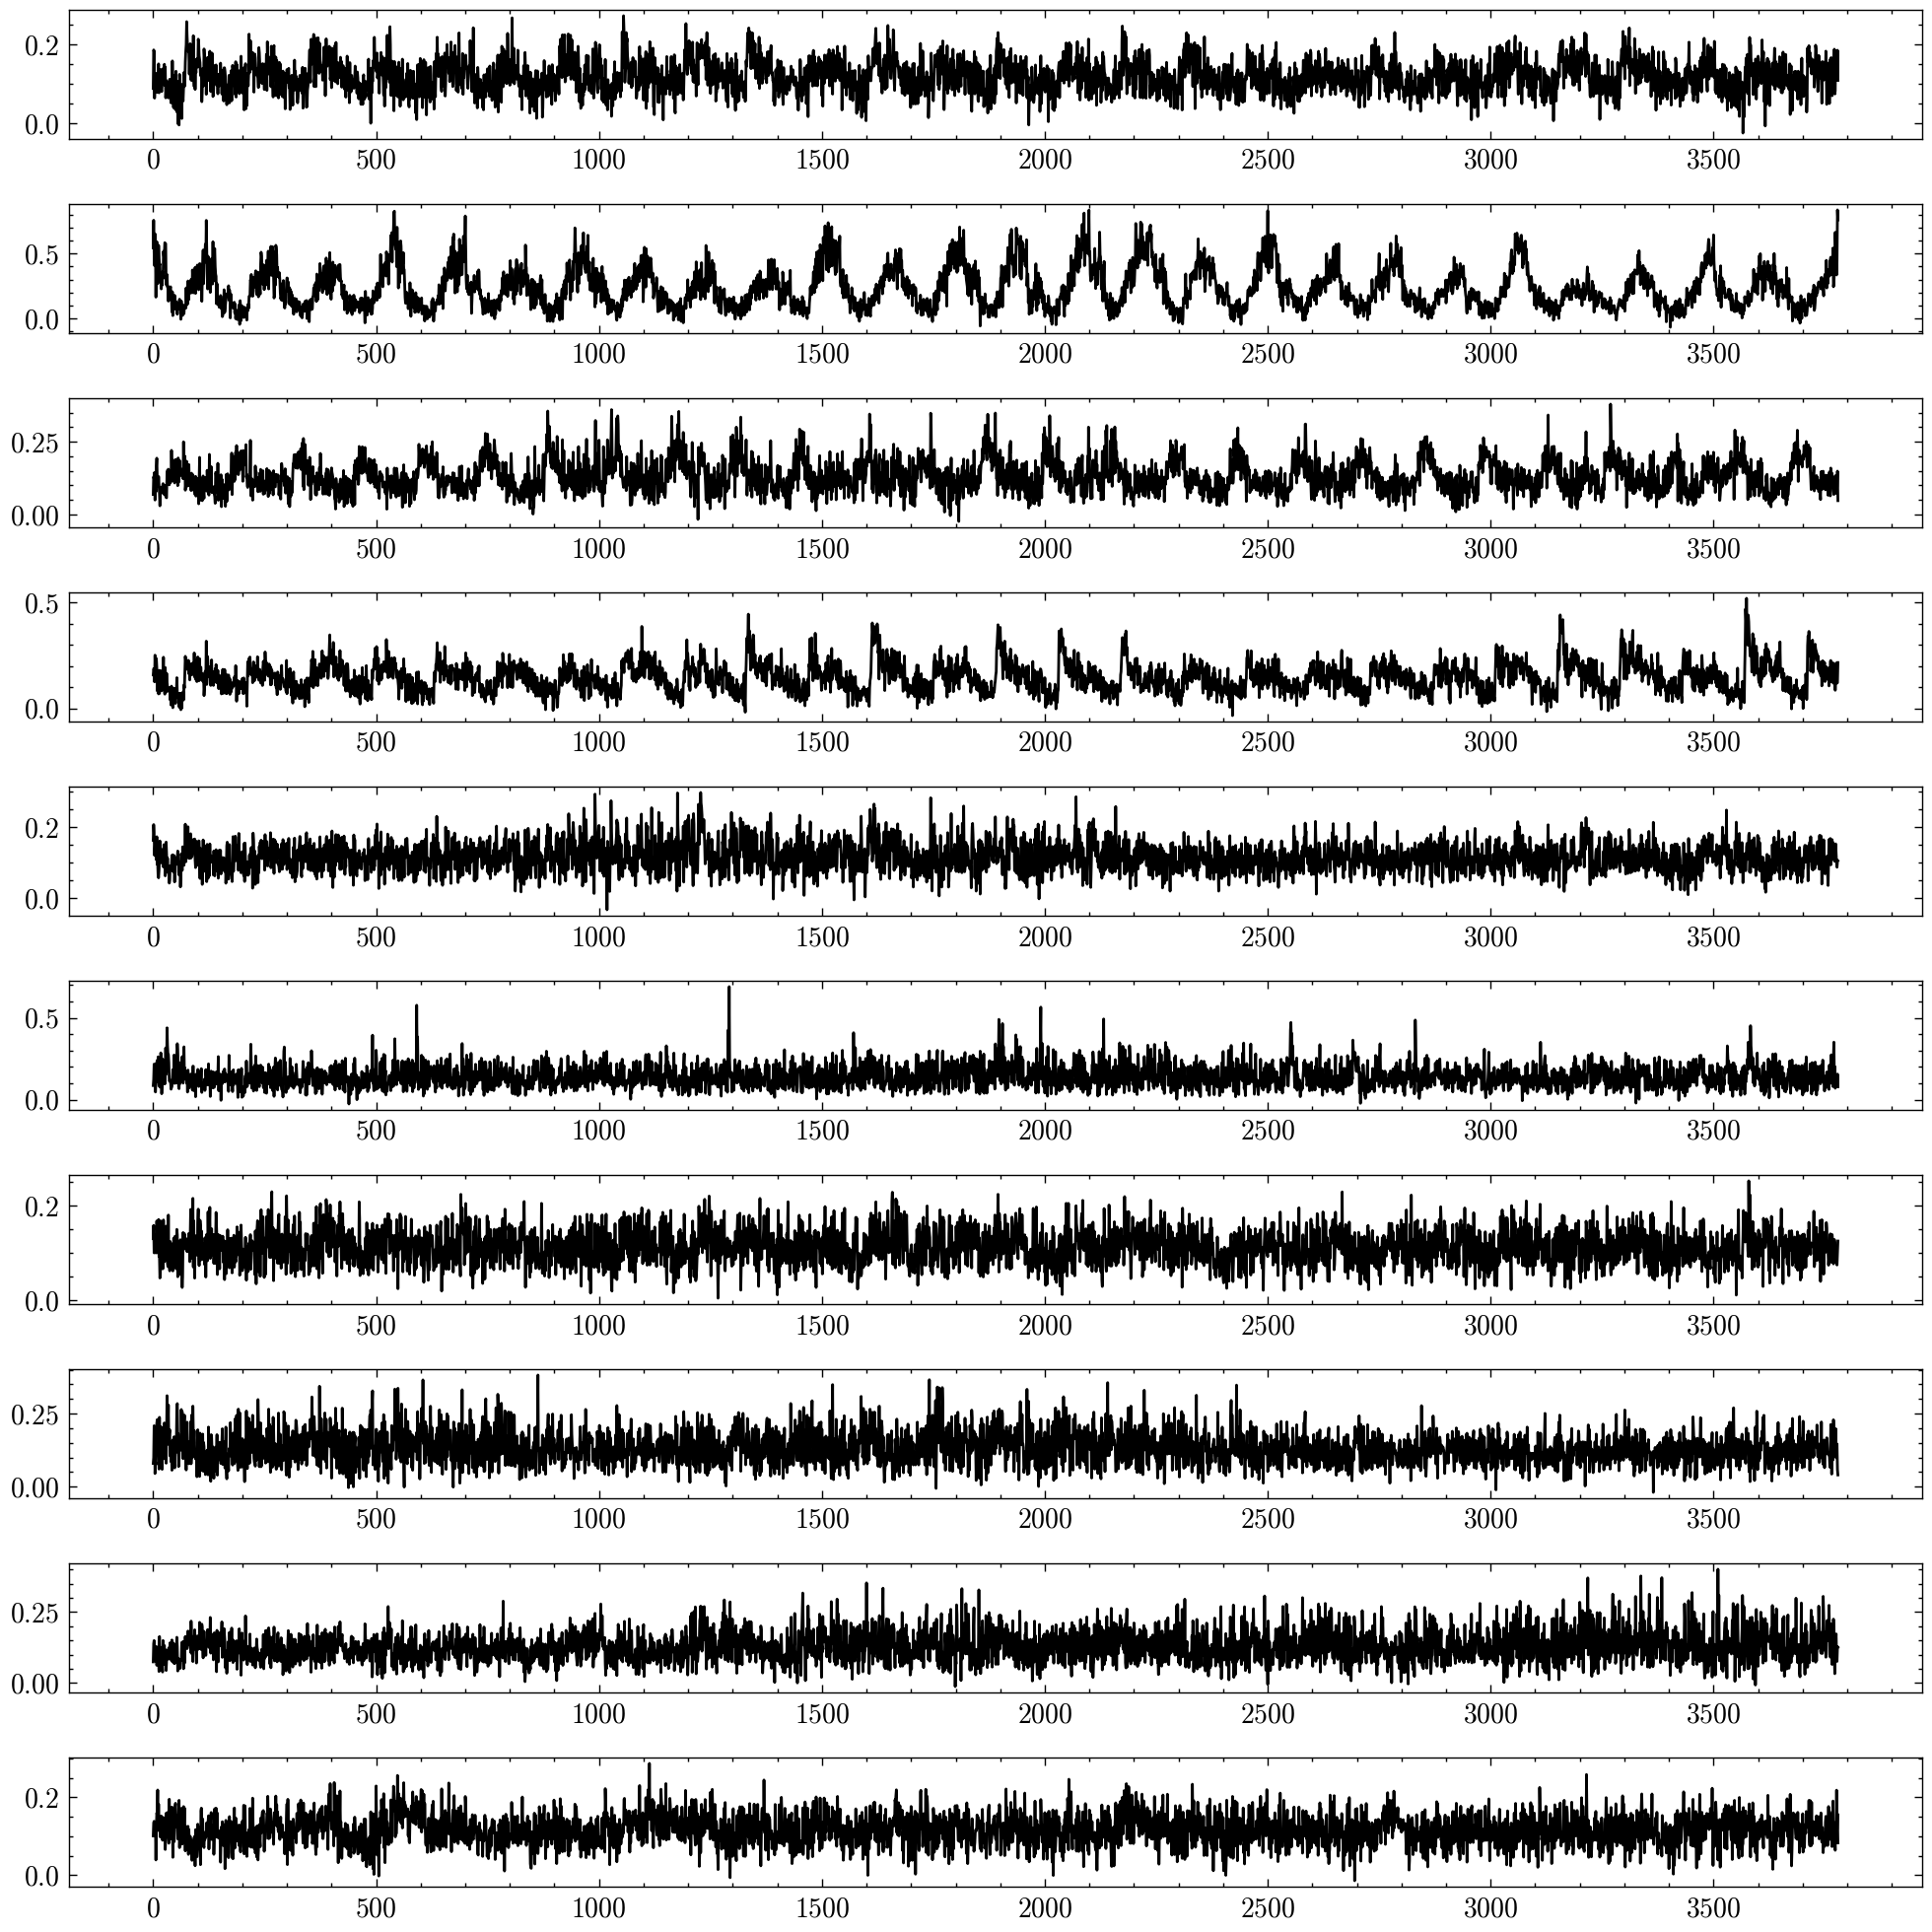

In [9]:
n_t, n_neurons = traces[..., valid_coordinate_i].shape

fig, axs = plt.subplots(10, figsize=(10, 10), dpi=200)
for i in range(0, 10):
  ax = axs[i]
  ax.plot(traces[..., valid_coordinate_i][..., i],'k',linewidth=1)
  # format_ax(ax)
  # ax.set_yscale('log')
plt.tight_layout()
plt.show()

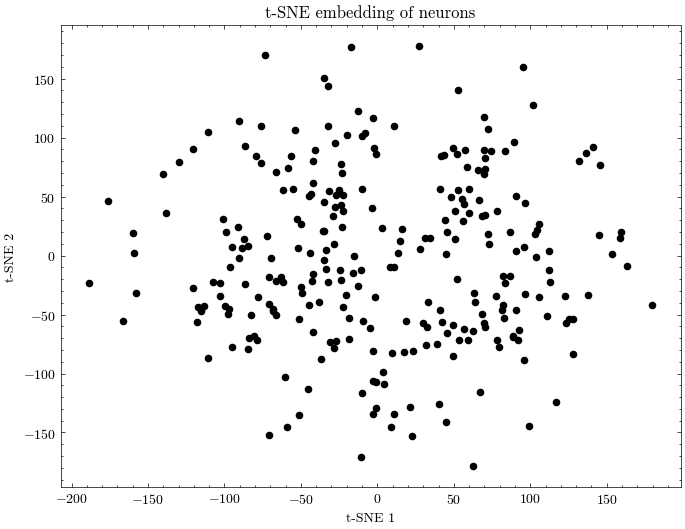

In [32]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

selected_idx = np.where(np.mean(traces[..., valid_coordinate_i], axis=0) > 0.13)[0]
selected_traces = traces[..., valid_coordinate_i][..., selected_idx]

X = selected_traces.T
X_scaled = StandardScaler().fit_transform(X)

# Use t-SNE with different parameters to improve separation and clustering clarity
tsne = TSNE(
    n_components=3,
    perplexity=3,    # lower perplexity can help with small sample sizes
    learning_rate=200, # default is 200, but can be tuned (try 100-1000)
    n_iter=2000,      # more iterations for more stable solution
    init='pca',       # pca initialization helps with reproducibility and clarity
    random_state=0
)
embedding = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(embedding[:, 0], embedding[:, 1], c='k', s=20)
plt.title('t-SNE embedding of neurons')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()


In [37]:
np.array(valid_coordinate_i)[selected_idx]

array([19124, 19136, 19146, 19160, 19177, 22526, 22562, 22689, 22778,
       26281, 26293, 26370, 26413, 29707, 29734, 29758, 29762, 29821,
       29827, 29863, 30178, 30257, 30278, 30301, 30382, 33813, 33848,
       33866, 33908, 33915, 33916, 33937, 33953, 33993, 34220, 34295,
       34296, 34309, 34315, 34321, 34389, 34412, 34479, 37812, 37886,
       37902, 37910, 37944, 37963, 38033, 38063, 38072, 38108, 38132,
       38383, 38473, 38563, 38768, 41922, 41949, 42029, 42030, 42046,
       42119, 42141, 42154, 42160, 42226, 42259, 42301, 42343, 42544,
       42589, 42615, 42684, 42707, 42956, 45837, 45875, 46001, 46191,
       46359, 46455, 46468, 46523, 46630, 46642, 46651, 46805, 46829,
       46977, 46996, 47169, 49942, 50050, 50078, 50145, 50256, 50310,
       50510, 50511, 50556, 50600, 50678, 50734, 50742, 50745, 50752,
       50765, 50772, 50787, 50797, 50802, 51057, 54002, 54044, 54360,
       54420, 54466, 54485, 54592, 54622, 54751, 54762, 54765, 54787,
       54793, 54795,

In [ ]:
idx = np.where(np.mean(traces[..., valid_coordinate_i], 0)>0.2)[0]
len(idx)

In [ ]:
n_t, n_neurons = traces[..., valid_coordinate_i][..., idx].shape
trace_avg = np.mean(traces, -1)
fig, axs = plt.subplots(30, figsize=(10, 20), dpi=200)
for i in range(0, 30):
  ax = axs[i]
  ax.plot(traces[..., valid_coordinate_i][..., idx][..., i],'k',linewidth=2)
  # ax.plot(trace_avg,'k',alpha=0.5, linewidth=2)
  # format_ax(ax)
  # ax.set_yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
plt.plot(np.mean(traces[..., valid_coordinate_i][..., idx], -1),'k',linewidth=1)
plt.plot(np.var(traces[..., valid_coordinate_i][..., idx], -1),'k',linewidth=1)

In [ ]:
plt.plot(np.mean(traces[..., valid_coordinate_i][..., idx], -1),'k',linewidth=1)
plt.plot(np.var(traces[..., valid_coordinate_i][..., idx], -1),'k',linewidth=1)

In [ ]:
plt.plot(np.mean(traces[..., np.random.randint(0, coordinates.shape[0], len(valid_coordinate_i))], -1),'k',linewidth=1)
plt.plot(np.var(traces[..., np.random.randint(0, coordinates.shape[0], len(valid_coordinate_i))], -1),'k',linewidth=1)

In [ ]:
# plt.plot(np.mean(traces, -1),'k',linewidth=1)
plt.plot(np.var(traces, -1),'k',linewidth=1)

Find neurons with highest similarity to given neuron

In [ ]:
i = 0
plt.plot(traces[..., valid_coordinate_i][..., idx][..., i])

In [ ]:
from tqdm import tqdm
trace_i = traces[..., valid_coordinate_i][..., idx][..., i]
cfs = []
for j in tqdm(range(traces.shape[1])):
  cfs.append(np.corrcoef(traces[..., j], trace_i)[0, 1])

In [ ]:
n_c = 10
traces_c = traces[..., np.argsort(np.abs(cfs))[::-1][:n_c]]

In [ ]:
np.abs(cfs)[np.argsort(np.abs(cfs))[::-1]][:n_c]

In [ ]:
fig, axs = plt.subplots(n_c, figsize=(10, n_c//2), dpi=200)
for i in range(0, n_c):
  ax = axs[i]
  ax.plot(traces_c[..., i],'k',linewidth=2)
  format_ax(ax)
plt.tight_layout()
plt.show()

Check where they are

In [ ]:
grid = pv.wrap(reference_anat)
grid.spacing = [1.0, 1.0, 2.0]
valid_coordinates_correlation = coordinates[np.argsort(np.abs(cfs))[::-1][:n_c]]
valid_coordinates_correlation

In [ ]:
mask_idx_list = []
for i_x, i_y, i_z in valid_coordinates_correlation.astype(int):
  i_lin = matlab_to_linear(i_x, i_y, i_z, mask_shape[0], mask_shape[1])
  for ir_idx in np.where(ir == i_lin)[0]:
    mask_idx_list.append(np.where(jc < ir_idx)[0][-1])
mask_idx_list = np.unique(mask_idx_list)
mask_idx_list

In [ ]:
np.array(names)[mask_idx_list]

Now locate the regions where the correlated neurons are and check in the atlas if they are anatomically connected

In [ ]:
reference_anat = scipy.io.loadmat(f'{PATH}/Additional_mat_files/ReferenceBrain.mat')['anat_stack_norm']

ir = f['MaskDatabase']['ir'][:]  # Row indices (linear voxel indices)
jc = f['MaskDatabase']['jc'][:]  # Column pointers
data = f['MaskDatabase']['data'][:]  # Should be all ones

mask = np.zeros_like(reference_anat)
mask_shape = mask.shape

In [ ]:
for mask_idx in mask_idx_list:
  start_idx = jc[mask_idx]
  end_idx = jc[mask_idx + 1]
  for i in ir[start_idx:end_idx]:
    i_x, i_y, i_z = linear_to_3d_matlab(i, mask_shape[0], mask_shape[1])
    mask[i_x, i_y, i_z] = 1

In [ ]:
# reference_anat[mask==0] = 0
grid = pv.wrap(reference_anat)
grid.spacing = [1.0, 1.0, 2.0]

valid_coordinates = coordinates[np.argsort(np.abs(cfs))[::-1][:n_c]]
points = valid_coordinates * np.array(grid.spacing)
point_cloud = pv.PolyData(points)
colors = np.abs(cfs)[np.argsort(np.abs(cfs))[::-1][:n_c]]

plotter = pv.Plotter(notebook=True)
plotter.add_volume(
    grid,
    cmap="gray",
    opacity=[0.0,0.1,0.3,0.5],
    shade=True,
    show_scalar_bar=False,
)

plotter.add_mesh(
    point_cloud,
    scalars=colors,
    cmap='viridis',
    point_size=30,
    render_points_as_spheres=True,
    show_scalar_bar=False
)

plotter.camera_position = 'xy'
plotter.camera.azimuth = 0
plotter.camera.elevation = 0
plotter.camera.zoom(1.5)
plotter.show()

knn predictability

In [ ]:
from sklearn.neighbors import NearestNeighbors

def find_neighborhoods(x, n_neighbors: int = 50, metric: str = "minkowski", p: int = 2):
    """
    Find neighborhoods for the test dataset.

    Args:
        x: Dataset.
        n_neighbors: Number of neighbors for neighborhood estimation. Defaults to 50.
    """
    # Fit k-nearest neighbors for the test dataset
    k_nearest_neighbors = NearestNeighbors(
            n_neighbors=n_neighbors, metric=metric, p=p
        ).fit(x)
    _, ix_neighborhoods = k_nearest_neighbors.kneighbors(x)
    return ix_neighborhoods

In [ ]:
context = 32
horizon = 1
n_neurons = traces.shape[-1]
traces.shape[0]-context-horizon
trace_data_x = np.stack([traces[i:i+context] for i in range(0, traces.shape[0]-context-horizon, 100)])
trace_data_theta = np.stack([traces[i+context+horizon] for i in range(0, traces.shape[0]-context-horizon, 100)])

In [ ]:
trace_data_x = trace_data_x.transpose(0, 2, 1).reshape(trace_data_x.shape[0]*n_neurons, context)
trace_data_theta = trace_data_theta.ravel()

In [ ]:
ix_neighborhoods = find_neighborhoods(trace_data_x[::10], n_neighbors=100)

In [ ]:
i = 0
plt.figure(dpi=500)
plt.scatter(trace_data_x[::10, 0], trace_data_x[::10, 1],c="k",marker=".",s=1)
plt.scatter(trace_data_x[::10][ix_neighborhoods[i]][:, 0], trace_data_x[::10][ix_neighborhoods[i]][:, 1],c="r",marker=".",s=5)

In [ ]:
from scipy.stats import gaussian_kde
kde = gaussian_kde(theta_hat)
x_grid = np.linspace(theta_hat.min(), theta_hat.max(), len(theta_hat))
plt.plot(x_grid, kde(x_grid))
plt.xlim(0, 1)

In [ ]:
np.mean([trace_data_theta[ix_neighborhoods[i]].mean() for i in range(ix_neighborhoods.shape[0])])

In [ ]:
def find_closest_theta(x, traces_x, traces_theta, n = 200):
  distances = np.linalg.norm(traces_x - x, axis=1)
  closest_ix = np.argsort(distances)[:n]
  closest_theta = traces_theta[closest_ix]
  return closest_theta

k = 3
predicted_trace_i = []
theta_hat_i = []
for j in tqdm(range(0, 300)):
  theta_hat = find_closest_theta(traces[:, valid_coordinate_i[k]][j:j+context], trace_data_x[::10], trace_data_theta[::10])
  theta_hat_i.append(theta_hat)
  predicted_trace_i.append(theta_hat.mean())

In [ ]:
theta_hat_i = np.array(theta_hat_i)

In [ ]:
plt.figure(figsize=(10, 1), dpi=500)
plt.plot(traces[context:300, valid_coordinate_i[k]], 'k')
plt.plot(np.quantile(theta_hat_i, 0.5, axis=-1), 'r')
plt.fill_between(
  np.arange(theta_hat_i.shape[0]),
  np.quantile(theta_hat_i, 0.05, axis=-1),
  np.quantile(theta_hat_i, 0.95, axis=-1),
  color='red',
  alpha=0.1,
  linewidth=0,
);